Name: B Lohith Krishnan

Roll Number: CH.SC.U4CSE24153

Department: CSE

Section: B

# Exercise 1: Predict Taxi Fare from Trip Miles

Train a model to predict the fare of a taxi ride in Chicago based on trip distance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Importing Dataset

In [2]:
df = pd.read_csv('../Data/chicago_taxi_trips.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (500, 2)


,trip_miles,fare
0,4.36,20.93
1,14.55,58.12
2,11.79,46.02
3,10.89,42.18
4,7.02,27.01


## Checking for any null values in dataset

In [3]:
df.isnull().sum()

trip_miles    0
fare          0
dtype: int64

## Assigning Dependent and Independent variables

In [4]:
x = df[['trip_miles']]
y = df['fare']

## Splitting the dataset into Training and Testing Dataset

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
print(f"Training set size: {x_train.shape[0]}")
print(f"Testing set size: {x_test.shape[0]}")

Training set size: 400
Testing set size: 100


## Fitting the Model (Linear Regression)

In [7]:
mdl = LinearRegression()
mdl.fit(x_train, y_train)
print(f"Intercept: {mdl.intercept_:.2f}")
print(f"Coefficient: {mdl.coef_[0]:.2f}")

Intercept: 3.38
Coefficient: 3.53


## Evaluation Metrics

In [8]:
y_pred = mdl.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

MSE: 4.76
R2: 0.98


## Plot

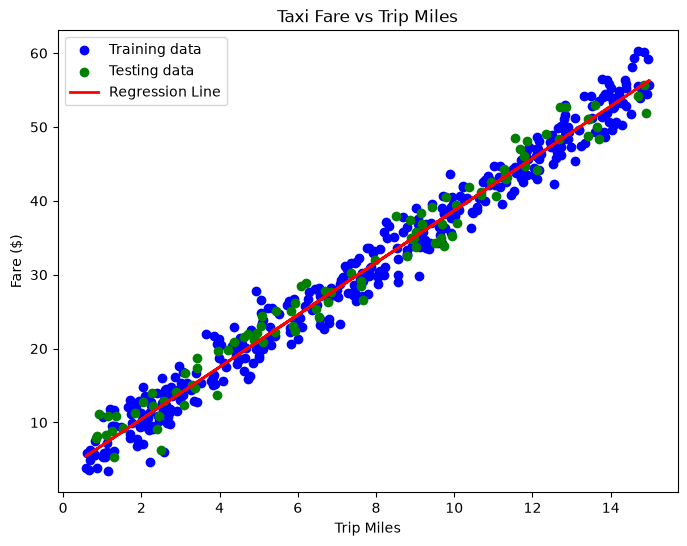

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.scatter(x_test, y_test, color='green', label='Testing data')
plt.plot(x, mdl.predict(x), color='red', linewidth=2, label='Regression Line')
plt.title('Taxi Fare vs Trip Miles')
plt.xlabel('Trip Miles')
plt.ylabel('Fare ($)')
plt.legend()
plt.show()